In [58]:
import numpy as np
from matplotlib.pyplot import*
from scipy import stats as st
from scipy import optimize as op
from scipy import fftpack
from scipy import signal
from scipy.special import erf
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from scipy.integrate import *
%matplotlib inline   

In [289]:
Nx=100;Ny=100
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=2# durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps
Ne=Nt//100

xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
t=np.linspace(0,1,Ne+1)
y,x=np.meshgrid(yy,xx)
#x,y=np.meshgrid(xx,yy)
inclusion=[]
for i in range(Nx+1):
    inclusion.append([False]*(Nx+1))
theta=np.zeros((Nx+1,Ny+1)) 
theta_e=np.zeros((Nx+1,Ny+1,Ne+1)) # pour échantilloner et avoir accés au champ de température à chaque instant échantilloné

x1=.5    #parametres géométriques de la bulle
y1=.5
r=.1

for i in range(1,4):
    for j in range(1,4):
        x1=i/4
        y1=j/4
        inclusion=np.bitwise_or(inclusion,(x-x1)**2+(y-y1)**2<=r**2)

#matrices de conductivité, masses volumiqes et capacité thermiques massiques
kappa=x*0+1
mu=x*0+1
c=x*0+1

#inclusion=(x-x1)**2+(y-y1)**2<=r**2

#on superpose au tableau des valeurs le tableau inclusion
kappa[inclusion]=1.e-1
mu[inclusion]=1.
c[inclusion]=1.

muc=mu*c                                                      
                                #deux disques
inclusion=[]
for i in range(Nx+1):
    inclusion.append([False]*(Nx+1))
    
#inclusion=np.bitwise_or((x-x1)**2+(y-y1)**2<=r**2,(x-x2)**2+(y-y2)**2<=r**2)
#print(inclusion)
#inclusion=np.array(([False]*Nx) for i in range(Nx))

        
#for i in range(1,4):
 #   y1=i/4
  #  inclusion=np.bitwise_or(inclusion,(x-x1)**2+(y-y1)**2<=r**2)
    


# faire des conditions pour pouvoir générer aléatoirement plusieurs inclusions 

#disque
#inclusion=(x-x1)**2+(y-y1)**2<=r**2


#bande
#inclusion=np.bitwise_and(y<=y1,y>=x1)
#inclusion=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x<=x1)
#cuivre=np.bitwise_and(np.bitwise_and(y<=y1,y>=-y1),x>x1)

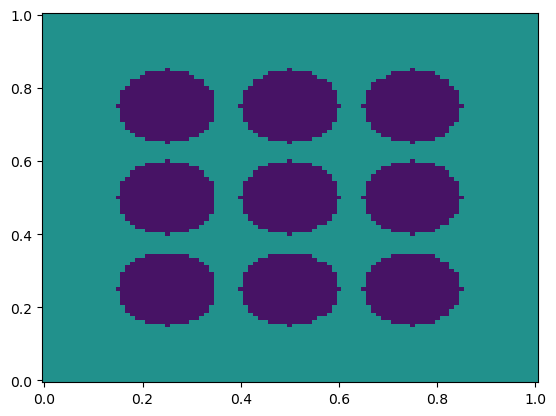

In [290]:
#imshow(theta,interpolation='none',cmap='coolwarm')#,vmin=0, vmax=.1,aspect='auto')
#imshow(production,interpolation='bilinear',cmap='gray',alpha=0.1)#,vmin=np.min(theta), vmax=np.max(theta),aspect='auto',alpha=.1)
#imshow(kappa,interpolation='none',cmap='copper',alpha=1)#,vmin=np.min(theta), vmax=np.max(theta),aspect='auto',alpha=.1)

pcolormesh(xx,yy,kappa, vmin=0, vmax=2)
savefig("inclusions néoprène 2D")

In [291]:

print(Nt)
for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                    +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                        +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                    +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=theta[1,::]
    theta[Nx,::]=theta[Nx-1,::]
    theta[::,0]=1 # paroi adiabatique à gauche (on crée un j nul)
    theta[::,Ny]=0#paroi adiabatique à droite (on crée un j nul)
    if j%100==0: 
        theta_e[:,:,j//100]=theta[:,:]
        

399999


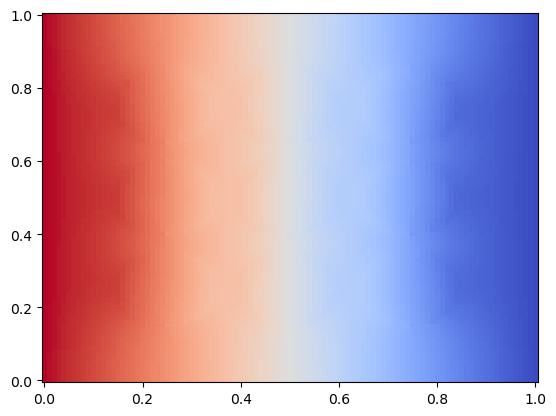

In [292]:
pcolormesh(xx,yy,theta_e[:,:,3999],cmap='coolwarm')
savefig("1 bulle")

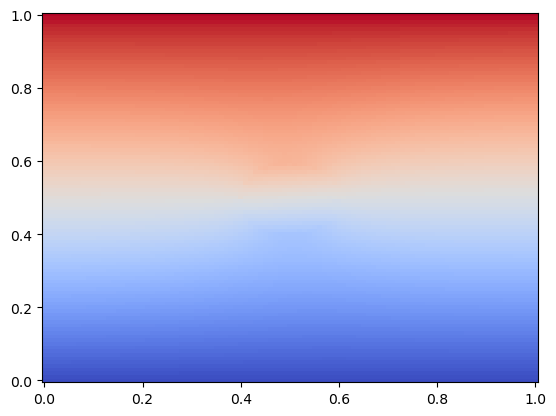

In [258]:

test=0
fichier=open("theta_e.txt","w+")


for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                    +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                        +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                    +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=0
    theta[Nx,::]=1
    theta[::,0]=theta[::,1] # paroi adiabatique à gauche (on crée un j nul)
    theta[::,Ny]=theta[::,Ny-1]#paroi adiabatique à droite (on crée un j nul)
    if j%100==0: 
        theta_e[:,:,j//100]=theta[:,:]
        
pcolormesh(xx,yy,theta_e[:,:,400],cmap='coolwarm')

In [293]:
#j=np.sum(kappa[1:,:]*(theta_e[1:,:,2499]-theta_e[:-1,:,2499]),axis=1)
j=-np.sum(kappa[:,1:]*(theta_e[:,1:,3999]-theta_e[:,:-1,3999]),axis=0)

#plot(xx[:-1],j)
#theta_e[1:,:,50]-theta_e[:-1,:,50]
j

array([0.62094306, 0.62096908, 0.6210211 , 0.62109905, 0.62120282,
       0.62133218, 0.62148677, 0.62166601, 0.62186901, 0.62209457,
       0.62234101, 0.62260615, 0.62288721, 0.62318081, 0.62348289,
       0.62378882, 0.62409342, 0.62439113, 0.6246762 , 0.62494293,
       0.62518595, 0.62540054, 0.62558291, 0.62573049, 0.62584211,
       0.62591819, 0.62596072, 0.62597318, 0.62596034, 0.62592795,
       0.62588239, 0.6258303 , 0.6257782 , 0.62573216, 0.6256975 ,
       0.62567853, 0.62567831, 0.62569861, 0.62573976, 0.62580069,
       0.62587898, 0.62597101, 0.62607214, 0.626177  , 0.62627976,
       0.62637456, 0.6264558 , 0.62651859, 0.62655906, 0.62657467,
       0.62656442, 0.62652891, 0.6264703 , 0.62639216, 0.62629916,
       0.62619671, 0.62609064, 0.62598678, 0.6258906 , 0.62580689,
       0.62573953, 0.62569123, 0.6256634 , 0.6256561 , 0.62566796,
       0.62569627, 0.62573709, 0.62578537, 0.62583526, 0.62588036,
       0.62591404, 0.62592985, 0.62592188, 0.6258851 , 0.62581

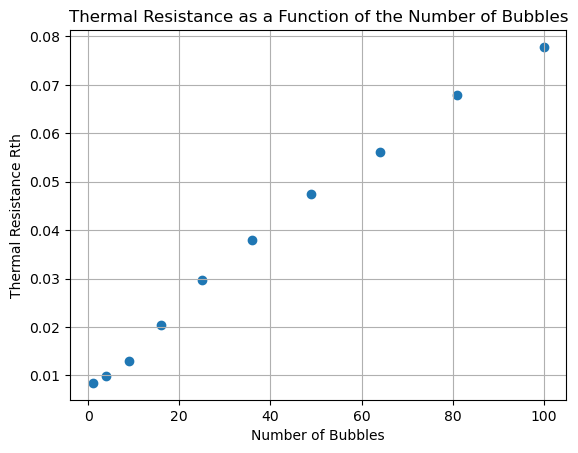

In [298]:
import numpy as np
import matplotlib.pyplot as plt

# Define grid and time step parameters
Nx, Ny = 100, 100
deltax, deltay = 1./Nx, 1./Ny
deltat = .05 * (deltay**2)
d = 2  # Duration of evolution
Nt = int(d / deltat)  # Number of time steps
Ne = Nt // 100

# Define spatial grid
xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
y, x = np.meshgrid(yy, xx)

# Parameters for bubble
r = 0.1

# Constants for thermal resistance calculation
L = 3e-3
kc = 0.37

# Initialize arrays to store results
num_bubbles_list = []
rth_values = []

# Function to initialize thermal properties
def initialize_properties(num_bubbles):
    inclusion = np.zeros((Nx+1, Ny+1), dtype=bool)
    for i in range(1, num_bubbles+1):
        for j in range(1, num_bubbles+1):
            x1, y1 = i / (num_bubbles + 1), j / (num_bubbles + 1)
            inclusion = np.bitwise_or(inclusion, (x - x1)**2 + (y - y1)**2 <= r**2)

    kappa = np.ones((Nx+1, Ny+1))
    mu = np.ones((Nx+1, Ny+1))
    c = np.ones((Nx+1, Ny+1))
    
    kappa[inclusion] = 0.1
    mu[inclusion] = 1.0
    c[inclusion] = 1.0
    
    return kappa, mu, c

# Loop over different numbers of bubbles
for num_bubbles in range(1, 11):  # Adjust to get 10 different values
    kappa, mu, c = initialize_properties(num_bubbles)
    muc = mu * c
    theta = np.zeros((Nx+1, Ny+1))
    theta_e = np.zeros((Nx+1, Ny+1, Ne+1))
    
    # Time evolution
    for j in range(Nt):
        theta[1:-1,1:-1] += (1. / muc[1:-1,1:-1] * (deltat / deltax * 
                        ((theta[2:,1:-1] - theta[1:-1,1:-1]) * kappa[2:,1:-1] / deltax +
                         (theta[:-2,1:-1] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltax) +
                         deltat / deltay * 
                        ((theta[1:-1,2:] - theta[1:-1,1:-1]) * kappa[1:-1,2:] / deltay +
                         (theta[1:-1,:-2] - theta[1:-1,1:-1]) * kappa[1:-1,1:-1] / deltay)))
        
        # Boundary conditions
        theta[0, :] = theta[1, :]
        theta[Nx, :] = theta[Nx-1, :]
        theta[:, 0] = 1  # Adiabatic wall on the left
        theta[:, Ny] = 0 # Adiabatic wall on the right
        
        if j % 100 == 0:
            theta_e[:, :, j//100] = theta[:, :]
    
    j_value = -np.sum(kappa[:, 1:] * (theta_e[:, 1:, Ne] - theta_e[:, :-1, Ne]), axis=0)
    j_mean = np.mean(j_value)
    
    # Calculate thermal resistance
    rth = L / (kc * j_mean)
    
    num_bubbles_list.append(num_bubbles**2)
    rth_values.append(rth)

# Plotting the results
plt.scatter(num_bubbles_list, rth_values, marker='o')
plt.xlabel('Number of Bubbles')
plt.ylabel('Thermal Resistance Rth')
plt.title('Thermal Resistance as a Function of the Number of Bubbles')
plt.grid(True)
plt.show()


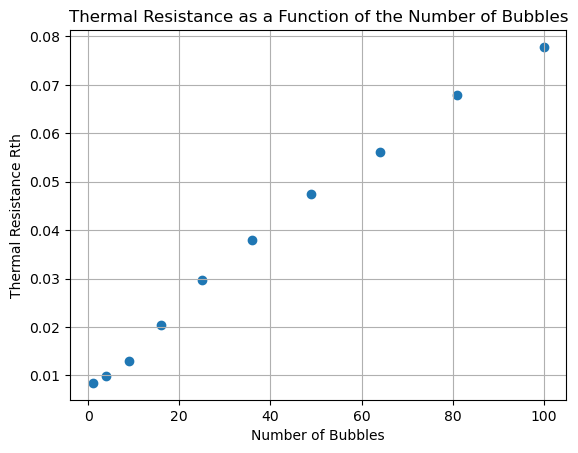

In [303]:
plt.scatter(num_bubbles_list, rth_values, marker='o')
plt.xlabel('Number of Bubbles')
plt.ylabel('Thermal Resistance Rth')
plt.title('Thermal Resistance as a Function of the Number of Bubbles')
plt.grid(True)
savefig('graphe')
plt.show()


# Approche statistique du nombre de bulle de leur repartition et du rayon 

0.7144

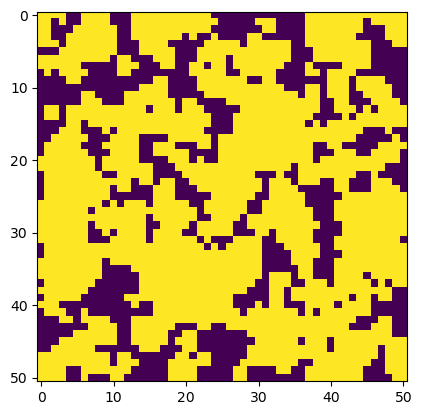

In [196]:
rv1=st.expon(loc=.02,scale=0.01)
rv2=st.uniform(0,1)

Nx=50;Ny=50
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=.2 # durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps


xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
y,x=np.meshgrid(yy,xx)


cond=x<-1
Nb=400
yc=rv2.rvs(Nb)
xc=rv2.rvs(Nb)
rc=rv1.rvs(Nb)

#plot(xc,yc,'ro')
savefig("placement des points")

for i in range(Nb): 
    bulle=(x-xc[i])**2+(y-yc[i])**2<=rc[i]**2 
    cond=np.bitwise_or(cond,bulle)
imshow(cond)
savefig("approche statistique") 
fraction=x*0
fraction[cond]=1
np.sum(np.sum(fraction,axis=0),axis=0)/(Nx*Ny)


In [197]:

deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)

d=5# durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps
Ne=Nt//100

xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
t=np.linspace(0,1,Ne+1)
y,x=np.meshgrid(yy,xx)
#x,y=np.meshgrid(xx,yy)

theta=np.zeros((Nx+1,Ny+1)) 
theta_e=np.zeros((Nx+1,Ny+1,Ne+1)) # pour échantilloner et avoir accés au champ de température à chaque instant échantilloné 

mu=x*0+1
c=x*0+1
kappa=x*0+1
#on superpose au tableau des valeurs le tableau inclusion
kappa[cond]=0.1
mu[cond]=1.
c[cond]=1.


muc=mu*c


In [198]:
#RS=False
for j in range(Nt):
    theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                        +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                         +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                         +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
    #C.L.
    theta[0,::]=1
    theta[Nx,::]=0 
    theta[::,0]=theta[::,1] # paroi adiabatique à gauche (on crée un j nul)
    theta[::,Ny]=theta[::,Ny-1]#paroi adiabatique à droite (on crée un j nul)
    if j%100==0: 
        theta_e[:,:,j//100]=theta[:,:]
        


array([-0.2038408 , -0.20347188, -0.20336164, -0.20441445, -0.20570545,
       -0.20957155, -0.21026291, -0.22849268, -0.2122374 , -0.21499635,
       -0.21384856, -0.24740932, -0.22462879, -0.2257783 , -0.20743991,
       -0.21039033, -0.22363087, -0.24579673, -0.26622758, -0.23888144,
       -0.20747   , -0.23430977, -0.23540598, -0.25815   , -0.23234841,
       -0.20624453, -0.2061786 , -0.20613105, -0.20609876, -0.20609256,
       -0.22960608, -0.23058086, -0.23034899, -0.20633963, -0.20642299,
       -0.20648971, -0.22673418, -0.20887907, -0.22841759, -0.20873752,
       -0.22826343, -0.21346629, -0.2144779 , -0.21442549, -0.20987239,
       -0.20981786, -0.20720214, -0.20582507, -0.20488417, -0.20390563])

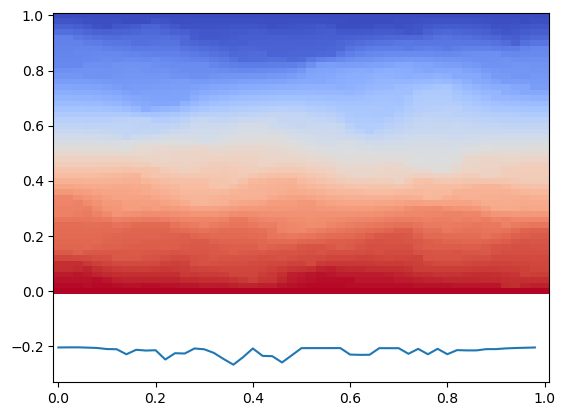

In [200]:
pcolormesh(xx,yy,theta_e[:,:,1500],cmap='coolwarm')
j=np.sum(kappa[1:,:]*(theta_e[1:,:,2499]-theta_e[:-1,:,2499]),axis=1)
plot(xx[:-1],j)
#theta_e[1:,:,50]-theta_e[:-1,:,50]
j

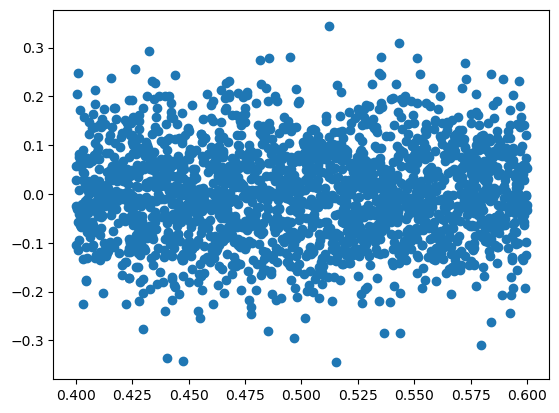

In [75]:
rv2=st.norm(loc=0,scale=0.1)
rv1=st.uniform(0,1)


Nb=10000
y=rv2.rvs(Nb)
x=rv1.rvs(Nb)

MM=[]
for i in range(Nb):
    MM.append([x[i],y[i]])
M=np.array(MM)

N=10
xmax=np.max(x)
xmin=np.min(x)
xmoy=(xmax+xmin)/2
dx=(xmax-xmin)/N

xe=np.linspace(xmin,xmax,N)

i=3

#MM[np.bitwise_and(M[0,:]<xmin+i*(xmax-xmin)/N,M[0,:]<xmin+(i+1)*(xmax-xmin)>N)]

a=M[np.bitwise_and(M[:,0]<xmoy+dx,M[:,0]>xmoy-dx)]

#scatter(M[:,0],M[:,1])

scatter(a[:,0],a[:,1])

numpy.ndarray

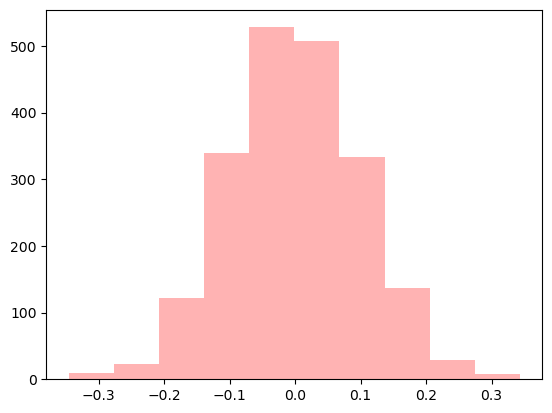

In [77]:
hist(a[:,1],bins=10,facecolor=(1., 0.7, 0.7))
type(a[:,1])

[-1.6087385291827074, -1.1095793843974548, -1.1888687031645029, -1.0794547313331049, -1.0464168439752148, -1.0463335658451234, -1.0463335658451234, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.5754834612148179, -0.575483461

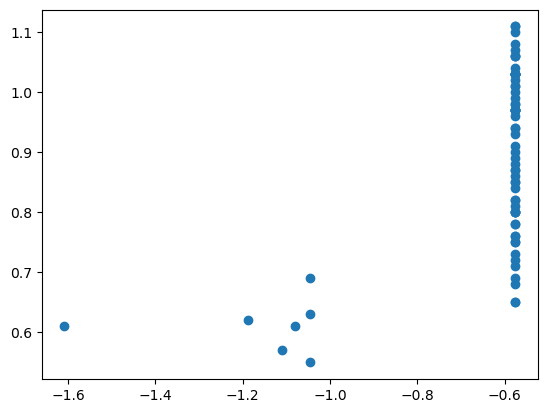

In [180]:
Nx=10;Ny=10
deltax=1./Nx;deltay=1./Ny
deltat=.05*(deltay**2)
d=.2 # durée de l'évolution
Nt=int(d/deltat) # nombre de pas de temps
xx=np.linspace(0,1,Nx+1)
yy=np.linspace(0,1,Ny+1)
t=np.linspace(0,1,Ne+1)
y,x=np.meshgrid(yy,xx)
test=0
jth=[]
occupation=[]
kappa=x*0+1
mu=x*0+1
c=x*0+1
simulation=10
for i in range(3,10):
    for sim in range(simulation):
        rv1=st.expon(loc=.02,scale=0.01)
        rv2=st.uniform(0,1)
        cond=x<-1
        Nb=i*100
        yc=rv2.rvs(Nb)
        xc=rv2.rvs(Nb)
        rc=rv1.rvs(Nb)
        for l in range(Nb): 
            bulle=(x-xc[l])**2+(y-yc[l])**2<=rc[l]**2 
            cond=np.bitwise_or(cond,bulle)
        #imshow(cond)
        test=test+1
        #savefig("approche statistique") 
        fraction=x*0
        fraction[cond]=1
        Ne=Nt//100
        theta=np.zeros((Nx+1,Ny+1)) 
        theta_e=np.zeros((Nx+1,Ny+1,Ne+1)) # pour échantilloner et avoir accés au champ de température à chaque instant échantilloné 
        mu=x*0+1
        c=x*0+1
        #on superpose au tableau des valeurs le tableau inclusion
        kappa[cond]=0.1
        mu[cond]=1.
        c[cond]=1.
        muc=mu*c
        for r in range(Nt):
            theta[1:-1,1:-1]+=1./muc[1:-1,1:-1]*(deltat/deltax*((theta[2:,1:-1]-theta[1:-1,1:-1])*kappa[2:,1:-1]/deltax
                                                        +(theta[:-2,1:-1]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltax)
                                         +deltat/deltay*((theta[1:-1,2:]-theta[1:-1,1:-1])*kappa[1:-1,2:]/deltay
                                                         +(theta[1:-1,:-2]-theta[1:-1,1:-1])*kappa[1:-1,1:-1]/deltay))
  
            theta[0,::]=1
            theta[Nx,::]=0 
            theta[::,0]=theta[::,1] 
            theta[::,Ny]=theta[::,Ny-1]
            if r%100==0: 
                theta_e[:,:,r//100]=theta[:,:]
        jth.append(np.sum(kappa[1:,:]*(theta_e[1:,:,Ne-1]-theta_e[:-1,:,Ne-1]),axis=1)[0])
        occupation.append(np.sum(np.sum(fraction,axis=0),axis=0)/(Nx*Ny))
print(jth)
print(occupation,len(occupation))
print(len(cond))
print(len(kappa))
scatter(jth,occupation)

# Partie du programme à revoir 

-0.47716650823993917
-0.3172392088984096
-0.2729827524506015
-0.25084642406694163
-0.26422933713358127
-0.277839846337756
-0.2745712446022631
-0.27227596631484446
-0.18771274130593874
-0.1876009263614271
-0.18713766064367285
-0.18712450007535586
-0.18712450007535586
-0.18712450007535586
-0.18712221202091137
-0.18712221202091137
-0.18712221202091137
-0.18712066853208678
-0.1871181911578338
-0.1871181911578338
[-0.47716650823993917, -0.3172392088984096, -0.2729827524506015, -0.25084642406694163, -0.26422933713358127, -0.277839846337756, -0.2745712446022631, -0.27227596631484446, -0.18771274130593874, -0.1876009263614271, -0.18713766064367285, -0.18712450007535586, -0.18712450007535586, -0.18712450007535586, -0.18712221202091137, -0.18712221202091137, -0.18712221202091137, -0.18712066853208678, -0.1871181911578338, -0.1871181911578338]
[0.4525, 0.3875, 0.345, 0.3575, 0.325, 0.38, 0.3625, 0.3875, 0.34, 0.3725, 0.52, 0.475, 0.4925, 0.485, 0.435, 0.435, 0.4325, 0.4325, 0.44, 0.4325]


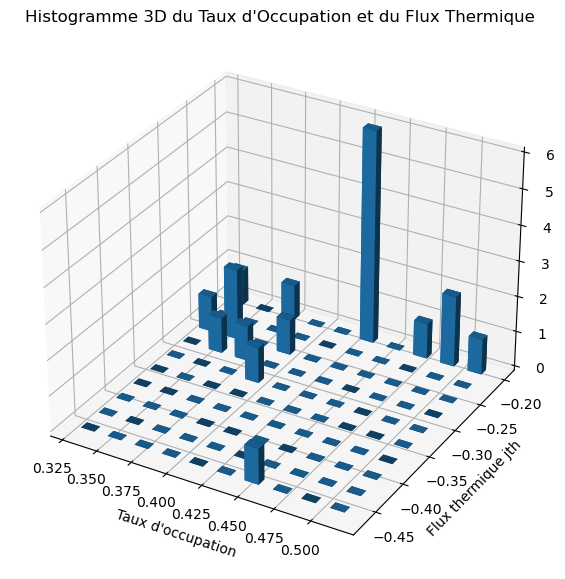

In [309]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Paramètres de la grille
Nx = 20
Ny = 20
deltax = 1. / Nx
deltay = 1. / Ny
deltat = .2 * (deltay ** 2)
d = 1.  # durée de l'évolution
Nt = int(d / deltat)  # nombre de pas de temps
Ne=10

xx = np.linspace(0, 1, Nx + 1)
yy = np.linspace(0, 1, Ny + 1)
t = np.linspace(0, 1, Ne + 1)
y, x = np.meshgrid(yy, xx)

jth = []
occupation = []

# Initialisation des paramètres des matériaux
kappa = x * 0 + 1
mu = x * 0 + 1
c = x * 0 + 1

simulation=10
conds=[]
for i in range(3, ):
    for sim in range(simulation):
        rv1 = st.expon(loc=.02, scale=.01)
        rv2 = st.uniform(0, 1)
        cond = x < -1
        Nb = i * 50
        yc = rv2.rvs(Nb)
        xc = rv2.rvs(Nb)
        rc = rv1.rvs(Nb)
        
        for l in range(Nb):
            bulle = (x - xc[l]) ** 2 + (y - yc[l]) ** 2 <= rc[l] ** 2
            cond = np.bitwise_or(cond, bulle)
        conds.append(cond)
        
        fraction = x * 0
        fraction[cond] = 1
        theta = np.zeros((Nx + 1, Ny + 1))
        theta_e = np.zeros((Nx + 1, Ny + 1, Ne + 1))
        
        # Mise à jour des paramètres des inclusions
        kappa[cond] = 0.1
        mu[cond] = 1.
        c[cond] = 1.
        muc = mu * c
        
        # Simulation de l'évolution de la température
        for r in range(Nt):
            theta[1:-1, 1:-1] += 1. / muc[1:-1, 1:-1] * (
                deltat / deltax * ((theta[2:, 1:-1] - theta[1:-1, 1:-1]) * kappa[2:, 1:-1] / deltax
                + (theta[:-2, 1:-1] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltax)
                + deltat / deltay * ((theta[1:-1, 2:] - theta[1:-1, 1:-1]) * kappa[1:-1, 2:] / deltay
                + (theta[1:-1, :-2] - theta[1:-1, 1:-1]) * kappa[1:-1, 1:-1] / deltay))
            
            # Conditions aux limites
            theta[0, :] = 1
            theta[Nx, :] = 0
            theta[:, 0] = theta[:, 1]
            theta[:, Ny] = theta[:, Ny - 1]
            if r==Nt-1:
                jth_value = np.sum(kappa[1:,:]*(theta[1:, :] - theta[:-1, :]), axis=1)[0]
                print(jth_value)
                jth.append(jth_value)
            
 #           if r % (Nt//Ne) == 0:
 #               theta_e[:, :, r // (Nt//Ne)] = theta[:, :]
        
        
        occupation_value = np.sum(fraction) / (Nx * Ny)
        
        #jth.append(jth_value)
        occupation.append(occupation_value)

# Affichage des résultats
print(jth)
print(occupation)

# Création de l'histogramme 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Nombre de bins pour les axes
num_bins = 10

# Calcul de l'histogramme
hist, xedges, yedges = np.histogram2d(occupation, jth, bins=num_bins)

# Créer les positions pour les barres du graphique 3D
xpos, ypos = np.meshgrid(xedges[:-1] + 0.25 * (xedges[1] - xedges[0]),
                         yedges[:-1] + 0.25 * (yedges[1] - yedges[0]),
                         indexing="ij")

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

# Hauteur des barres
dx = dy = 0.5 * (xedges[1] - xedges[0])
dz = hist.ravel()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, zsort='average')

# Labels et titre
ax.set_xlabel('Taux d\'occupation')
ax.set_ylabel('Flux thermique jth')
ax.set_zlabel('Nombre de simulations')
ax.set_title('Histogramme 3D du Taux d\'Occupation et du Flux Thermique')

plt.show()


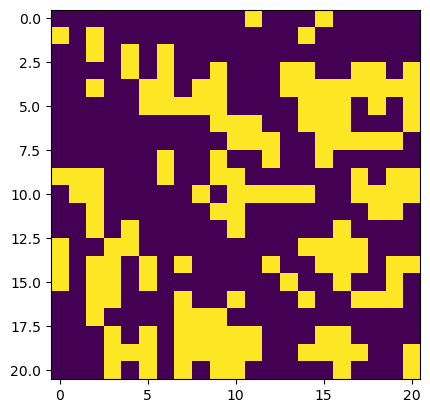

In [232]:
imshow(conds[22])